# Visualización 

En este documento se visualizara el comportamiento de los modelos, pero ahora usando usando un DataSet real y empezaremos con el DataSet *IRIS*, y empezamos con este debido a los siguientes aspectos:
- Gratuito 
- Esta en Sklearn 
- Es un clásico para ML
- Contiene 4 features

Sin embargo, para este ejercicio y notebook se utilizaran solamente dos para realizar una visualización


## 1.- Carga del DataSet y Librerias de python 


In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

## 2.- Cargar y preparar los datos

In [3]:
iris = load_iris()

X = iris.data[:, :2] # Se restrige a dos features para la visualizacion
y = iris.target

En la celda anterior de código sucede lo siguiente:
    En primera instancia se contiene la carga de las 4 caraccteristicas siendo estas las siguientes **Largo sépalo, Ancho Sépalo, Largo pétalo, ancho pétalo**.
    Por otro lado la linea de **[:, :2]** toma todas las filas del propio dataset, pero solo considera las dos primeras columnas. Esto para respetar que sea de dos DImensiones y para una mejos visualizacion de las fronteras

## 3.- Escalamiento

En esta parte se realizara un escalamiento del propio DataSet

In [4]:
scaler = StandardScaler()
X  = scaler.fit_transform(X)

Se realiza el escalamiento de los datos con el fin de que ninguna feature (caraccteristicas) domine en la distancia.

En los ***KNN***, si no se realiza un escalamiento se pueden obtener un resultado incorrecto. 

## 4.- División de Datos

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

A grandes rasgos la celda anterior realiza lo siguiente:

- 70% del dataset para entrenamiento
- 30% Para realizar pruebas
- **random_state = 42** asegura reproducibilidad y es semilla

## 5.- Creación de Modelos

In [6]:
knn_euclidean = KNeighborsClassifier(n_neighbors=15, metric="euclidean")
knn_manhattan = KNeighborsClassifier(n_neighbors=15, metric="manhattan")

knn_euclidean.fit(X_train, y_train)
knn_manhattan.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


En la celda anterior se realiza lo siguiente:

- **n_neighbors=5** es la votación de entre 5 vecinos
- **metric** define la distancia o el modelo.
- **.fit** entrena el modelo (***pero recordando KNN solo guarda datos no aprende pesos, es decir solo memoriza el dataset***)

## 6.- Evaluación

In [7]:
print("Accuracy Euclidian: ", knn_euclidean.score(X_test, y_test))
print("Accuracy Manhattan: ", knn_manhattan.score(X_test, y_test))

Accuracy Euclidian:  0.7111111111111111
Accuracy Manhattan:  0.7777777777777778


A grandes rasgos la celda anterior solo calcula cuan preciso es el modelo de KNN

# Visualizando desde otra perspectiva 

En este otra perspectiva omitiremos el paso de la importación de librerias, carga del propio DataSet, la divisíon del entrenamiento y del test para comnezar directamente con el escalamiento de los datos

In [8]:
# Escalamiento
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [9]:
# Entrenamiento de nuevo de los modelos 
k_values = range(1, 21)
acc_manhattan = []
acc_euclidean = []

for k in k_values:
    # Manhattan
    knn_l1 = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    knn_l1.fit(X_train, y_train)
    y_pred_l1 = knn_l1.predict(X_test)
    acc_manhattan.append(accuracy_score(y_test, y_pred_l1))

    # Euclidiana
    knn_l2 = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_l2.fit(X_train, y_train)
    y_pred_l2 = knn_l2.predict(X_test)
    acc_euclidean.append(accuracy_score(y_test, y_pred_l2))


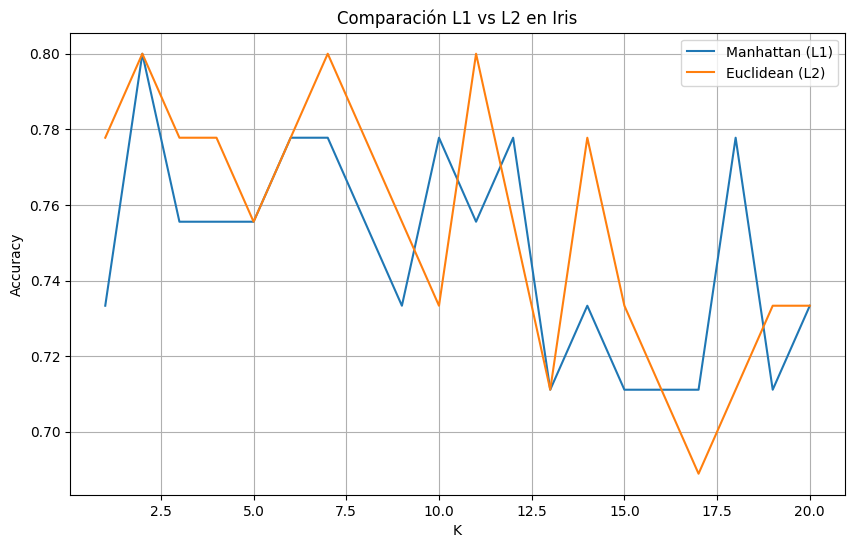

In [10]:
# Visualización de los datos mediante graficas 
plt.figure(figsize=(10,6))
plt.plot(k_values, acc_manhattan, label='Manhattan (L1)')
plt.plot(k_values, acc_euclidean, label='Euclidean (L2)')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Comparación L1 vs L2 en Iris')
plt.legend()
plt.grid()
plt.show()

## Agregación de ruido **Gaussiano**

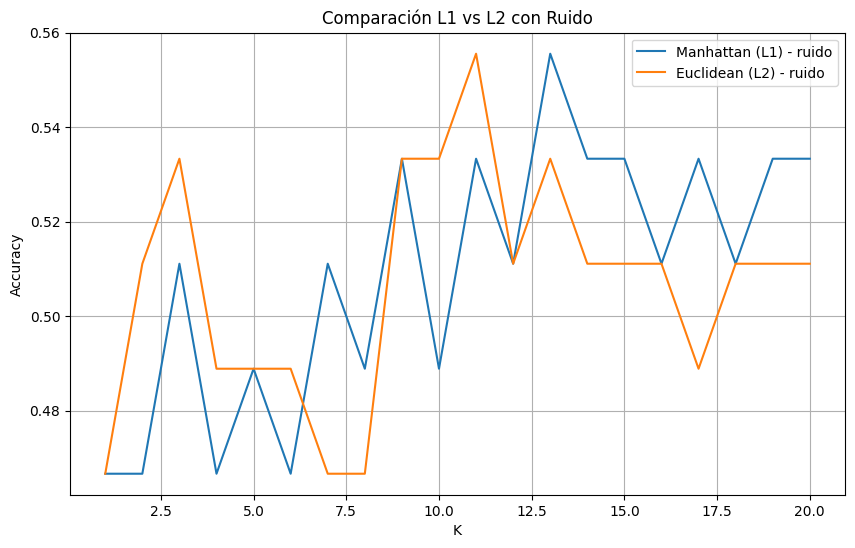

In [11]:


np.random.seed(42)

noise_strength = 1.0  

X_train_noisy = X_train + np.random.normal(0, noise_strength, X_train.shape)
X_test_noisy = X_test + np.random.normal(0, noise_strength, X_test.shape)

acc_manhattan_noise = []
acc_euclidean_noise = []

for k in k_values:
    knn_l1 = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    knn_l1.fit(X_train_noisy, y_train)
    y_pred_l1 = knn_l1.predict(X_test_noisy)
    acc_manhattan_noise.append(accuracy_score(y_test, y_pred_l1))

    knn_l2 = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_l2.fit(X_train_noisy, y_train)
    y_pred_l2 = knn_l2.predict(X_test_noisy)
    acc_euclidean_noise.append(accuracy_score(y_test, y_pred_l2))

#graficacion de los resultados
plt.figure(figsize=(10,6))
plt.plot(k_values, acc_manhattan_noise, label='Manhattan (L1) - ruido')
plt.plot(k_values, acc_euclidean_noise, label='Euclidean (L2) - ruido')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Comparación L1 vs L2 con Ruido')
plt.legend()
plt.grid()
plt.show()